# K-Means implementation from scratch

### Imports

Loads the core libraries needed for the whole notebook — **pandas** for tabular data handling, **numpy** for the vectorized math behind the model, **matplotlib** for visualization, **Counter** for matching clusters to real classes, and **load_breast_cancer** from scikit-learn as a real-data source.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_breast_cancer

### Loading Data

Loads all 569 real patients from the Breast Cancer Wisconsin dataset with all 30 real tumor measurements as features, and separately keeps the true diagnosis (malignant/benign).

In [11]:
data = load_breast_cancer(as_frame=True)
df = data.frame

X = df.drop(columns=["target"]).values.astype(float)
y = np.array(["malignant" if t == 0 else "benign" for t in df["target"].values])

print(f"Examples: {X.shape[0]}, Features: {X.shape[1]}")

Examples: 569, Features: 30


### Standardizing Features

Scales all 30 features to the same standardized range before clustering.

In [3]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

### K-Means Class

Implements the K-Means algorithm from scratch. Starts by picking **k** real patients at random as initial cluster centers ("centroids"), then repeats two steps until the centroids stop moving: assigns every patient to their nearest centroid, then moves each centroid to the average position of the patients now assigned to it. **inertia** measures how tightly grouped the final clusters are: the total squared distance from every point to its assigned centroid.

In [4]:
class KMeans:
    def __init__(self, k, max_iters=100, random_state=None):
        self.k = k
        self.max_iters = max_iters
        self.random_state = random_state

    def euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        random_idx = rng.choice(X.shape[0], self.k, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            clusters = self.assign_clusters(X)
            new_centroids = np.array([
                X[clusters == i].mean(axis=0) if np.any(clusters == i) else self.centroids[i]
                for i in range(self.k)
            ])

            if np.allclose(new_centroids, self.centroids):
                break

            self.centroids = new_centroids

        self.labels = self.assign_clusters(X)

    def assign_clusters(self, X):
        distances = np.array([[self.euclidean_distance(point, centroid) for centroid in self.centroids] for point in X])
        return np.argmin(distances, axis=1)

    def predict(self, X):
        return self.assign_clusters(X)

    def inertia(self, X):
        return np.sum([self.euclidean_distance(X[i], self.centroids[self.labels[i]]) ** 2 for i in range(len(X))])

### Applying K-Means

Runs the algorithm with **k=2**, matching the two real diagnosis categories on the standardized data.


In [5]:
kmeans = KMeans(k=2, random_state=2)
kmeans.fit(X_scaled)

print(f"Inertia: {kmeans.inertia(X_scaled):.2f}")

Inertia: 11595.46


**11595.46**: the total squared distance across all 569 patients to their final assigned cluster center.

### Comparing Clusters to Real Diagnoses

K-Means only outputs arbitrary cluster numbers (0 or 1) with no concept of "malignant" or "benign." This step maps each cluster to whichever real diagnosis is most common among the patients grouped into it, so the clustering result can be checked against ground truth.

In [6]:
cluster_to_class = {}
for cluster_id in range(2):
    true_labels_in_cluster = y[kmeans.labels == cluster_id]
    cluster_to_class[cluster_id] = Counter(true_labels_in_cluster).most_common(1)[0][0]

predicted_classes = np.array([cluster_to_class[c] for c in kmeans.labels])
agreement = np.mean(predicted_classes == y) * 100
print(f"Agreement with real diagnosis: {agreement:.2f}%")

Agreement with real diagnosis: 91.04%


**91.04% agreement** with the real diagnosis, meaning that just by grouping patients based on the geometric shape of their 30 real measurements, with zero access to diagnosis labels, the algorithm independently found a grouping that matches the real malignant/benign split over 9 times out of 10.

### Visualizing the Clusters

Plots two real, highly informative features (worst perimeter, worst concave points) side by side.

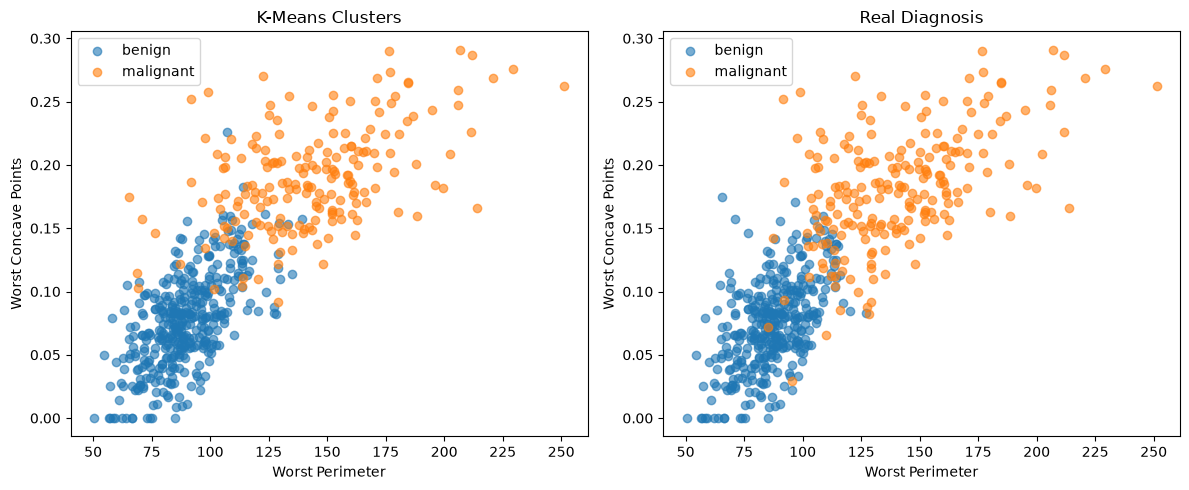

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# relabel cluster IDs as their matched diagnosis, so colors align across both panels
cluster_labels_as_diagnosis = np.array([cluster_to_class[c] for c in kmeans.labels])

for ax, labels, title in zip(axes, [cluster_labels_as_diagnosis, y], ['K-Means Clusters', 'Real Diagnosis']):
    for val, color in zip(['benign', 'malignant'], ['tab:blue', 'tab:orange']):
        mask = labels == val
        ax.scatter(X[mask, df.columns.get_loc('worst perimeter')],
                   X[mask, df.columns.get_loc('worst concave points')],
                   color=color, label=val, alpha=0.6)
    ax.set_xlabel('Worst Perimeter')
    ax.set_ylabel('Worst Concave Points')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

The two panels show clearly similar structure: the cluster boundary K-Means discovered lines up closely with where the real malignant/benign split falls in this feature space.

### Sklearn Validation

Fits scikit-learn's **KMeans** with the same **k=2** on the identical standardized data, as an independent correctness check.

In [10]:
from sklearn.cluster import KMeans as SkKMeans

sk_kmeans = SkKMeans(n_clusters=2, random_state=2, n_init=10)
sk_labels = sk_kmeans.fit_predict(X_scaled)

print(f"From scratch inertia: {kmeans.inertia(X_scaled):.2f}")
print(f"sklearn inertia:      {sk_kmeans.inertia_:.2f}")

From scratch inertia: 11595.46
sklearn inertia:      11595.46


Exact match: 11595.46 for both.